# Formative 1: Time Series EDA, Analysis, and Forecasting

In [29]:
# 1) Imports and setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 50)

# 2) Load and prepare dataset
csv_path = 'portfolio_data.csv'
df_raw = pd.read_csv(csv_path)

df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f'Shape: {df.shape}')
print(f'Numeric columns: {numeric_cols}')
df.head()

Shape: (1520, 4)
Numeric columns: ['AMZN', 'DPZ', 'BTC', 'NFLX']


,AMZN,DPZ,BTC,NFLX
Date,,,,
2013-05-01,248.229996,51.190983,106.250000,30.415714
2013-05-02,252.550003,51.987320,98.099998,30.641428
2013-05-03,258.049988,52.446388,112.900002,30.492857
2013-05-06,255.720001,53.205257,109.599998,30.098572
2013-05-07,257.730011,54.151505,113.199997,29.464285


Time range: 2013-05-01 to 2019-05-14 (2204 days)

Top date gaps (granularity clues):
Date
1 days    1188
2 days      16
3 days     276
4 days      39
Name: count, dtype: int64

Most common time gap: 1 days 00:00:00


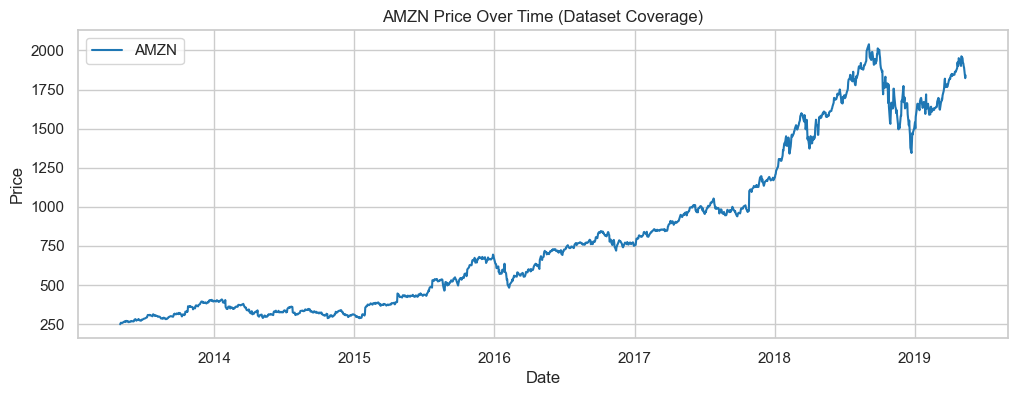

In [30]:
# A1) Time range and frequency / granularity
start_date = df.index.min()
end_date = df.index.max()
span_days = (end_date - start_date).days

print(f'Time range: {start_date.date()} to {end_date.date()} ({span_days} days)')

date_gap_counts = df.index.to_series().diff().value_counts().sort_index()
print('\nTop date gaps (granularity clues):')
print(date_gap_counts.head(10))

most_common_gap = df.index.to_series().diff().mode().iloc[0]
print(f'\nMost common time gap: {most_common_gap}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['AMZN'], label='AMZN', color='tab:blue')
ax.set_title('AMZN Price Over Time (Dataset Coverage)')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.show()

In [31]:
print('Interpretation: The series is approximately daily with weekend/holiday gaps, typical of market data.')

Interpretation: The series is approximately daily with weekend/holiday gaps, typical of market data.


,count,mean,std,min,25%,50%,75%,max
AMZN,1520.0,821.542,518.443,248.230,364.360,686.460,1121.288,2039.510
DPZ,1520.0,146.772,72.192,51.191,84.994,127.168,202.455,298.636
BTC,1520.0,2421.466,3310.894,69.660,340.905,625.305,3874.912,18972.320
NFLX,1520.0,147.668,107.641,29.464,62.851,104.000,192.207,418.970


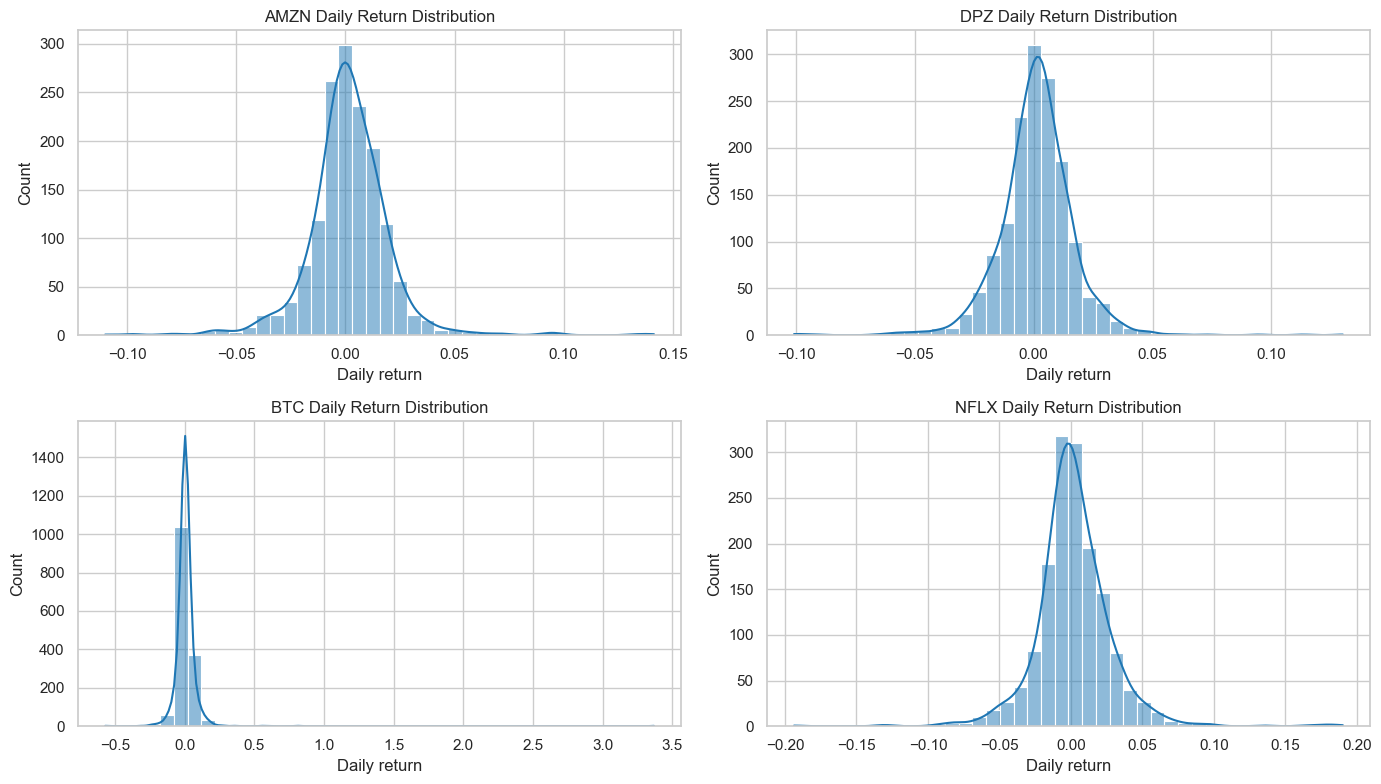

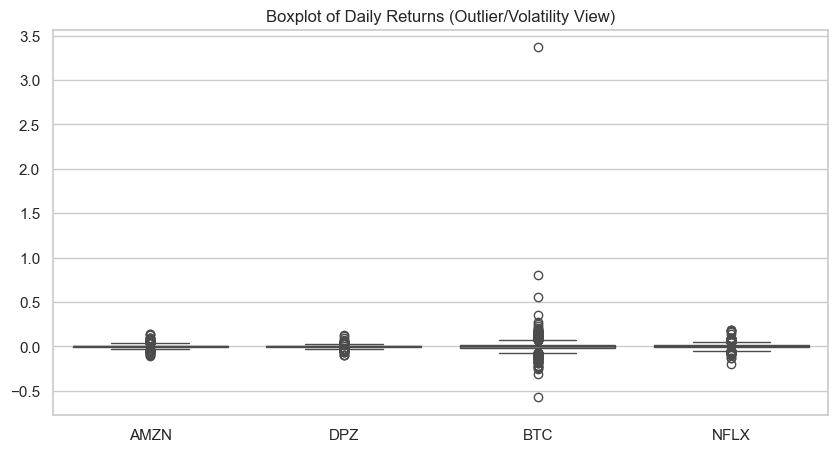

In [32]:
# A2) Statistical distribution of numerical columns
summary_stats = df[numeric_cols].describe().T.round(3)
display(summary_stats)

df_returns = df[numeric_cols].pct_change().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df_returns[col], kde=True, bins=40, ax=ax, color='tab:blue')
    ax.set_title(f'{col} Daily Return Distribution')
    ax.set_xlabel('Daily return')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_returns[numeric_cols], ax=ax)
ax.set_title('Boxplot of Daily Returns (Outlier/Volatility View)')
plt.show()

In [33]:
print('Interpretation: Return distributions are non-Gaussian with noticeable tails/outliers, especially for BTC.')

Interpretation: Return distributions are non-Gaussian with noticeable tails/outliers, especially for BTC.


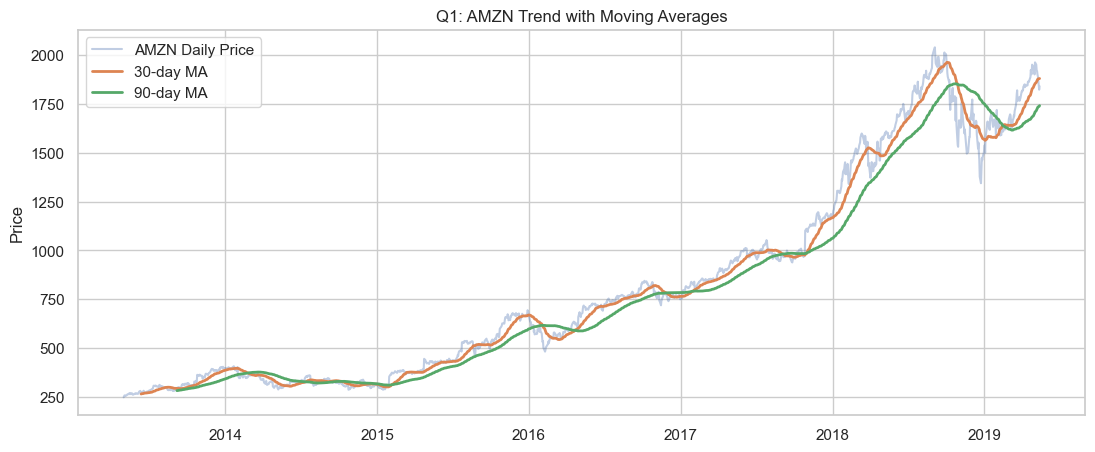

In [34]:
# Does AMZN show a long-term increasing trend?
amzn_trend = df[['AMZN']].copy()
amzn_trend['AMZN_30D_MA'] = amzn_trend['AMZN'].rolling(30).mean()
amzn_trend['AMZN_90D_MA'] = amzn_trend['AMZN'].rolling(90).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(amzn_trend.index, amzn_trend['AMZN'], alpha=0.35, label='AMZN Daily Price')
ax.plot(amzn_trend.index, amzn_trend['AMZN_30D_MA'], label='30-day MA', linewidth=2)
ax.plot(amzn_trend.index, amzn_trend['AMZN_90D_MA'], label='90-day MA', linewidth=2)
ax.set_title('Q1: AMZN Trend with Moving Averages')
ax.set_ylabel('Price')
ax.legend()
plt.show()

start_price = amzn_trend['AMZN'].iloc[0]
end_price = amzn_trend['AMZN'].iloc[-1]
growth_pct = (end_price / start_price - 1) * 100

In [35]:
print(f'Interpretation: AMZN moved from {start_price:.2f} to {end_price:.2f} ({growth_pct:.2f}% total growth).')
print('Moving averages reduce short-term noise and highlight the broader trend direction.')

Interpretation: AMZN moved from 248.23 to 1840.12 (641.30% total growth).
Moving averages reduce short-term noise and highlight the broader trend direction.


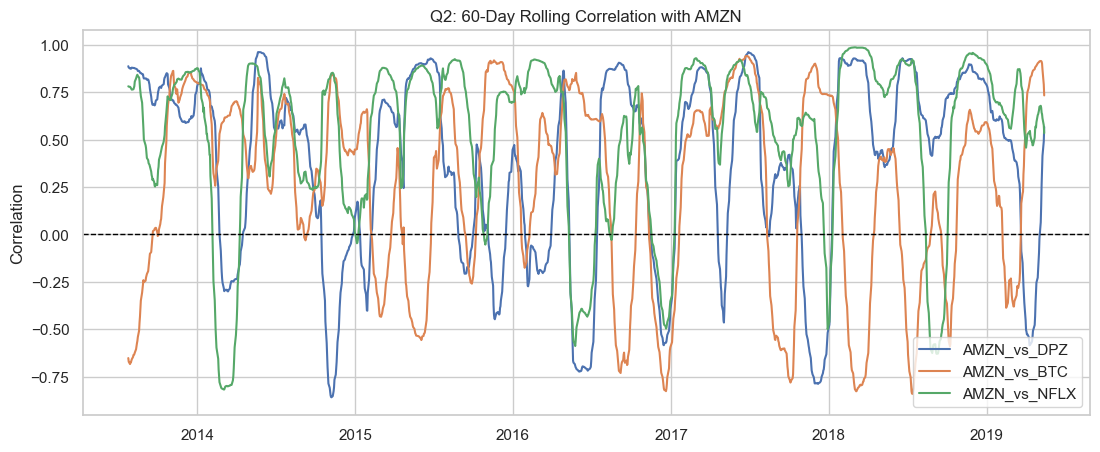

Static correlation with AMZN:
NFLX    0.980117
DPZ     0.972172
BTC     0.759802
Name: AMZN, dtype: float64


In [36]:
#Do DPZ, BTC, and NFLX correlate with AMZN over time?
rolling_window = 60
rolling_corr_df = pd.DataFrame(index=df.index)
for asset in ['DPZ', 'BTC', 'NFLX']:
    rolling_corr_df[f'AMZN_vs_{asset}'] = df['AMZN'].rolling(rolling_window).corr(df[asset])

fig, ax = plt.subplots(figsize=(13, 5))
for series_name in rolling_corr_df.columns:
    ax.plot(rolling_corr_df.index, rolling_corr_df[series_name], label=series_name)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title(f'Q2: {rolling_window}-Day Rolling Correlation with AMZN')
ax.set_ylabel('Correlation')
ax.legend()
plt.show()

corr_static = df[['AMZN', 'DPZ', 'BTC', 'NFLX']].corr()['AMZN'].drop('AMZN').sort_values(ascending=False)
print('Static correlation with AMZN:')
print(corr_static)

In [37]:
print('\nInterpretation: Correlations vary across time; rolling correlation reveals changing relationships.')


Interpretation: Correlations vary across time; rolling correlation reveals changing relationships.


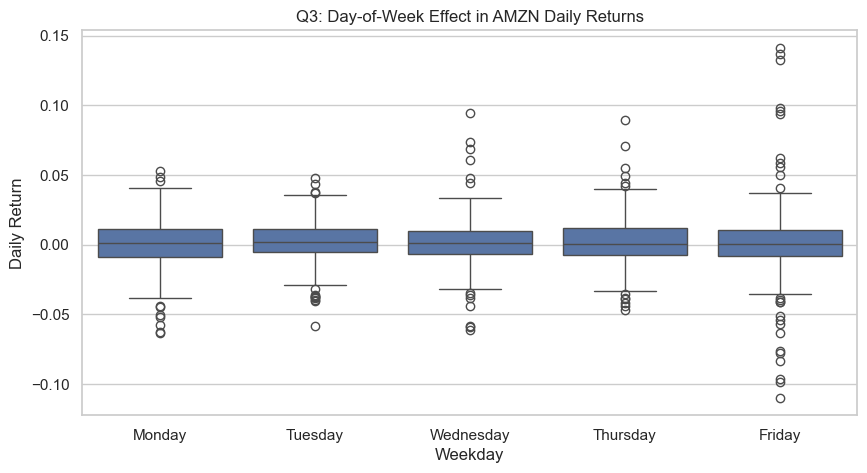

               mean       std    median  count
weekday                                       
Monday     0.000190  0.017472  0.001105    286
Tuesday    0.002453  0.014769  0.002125    312
Wednesday  0.001741  0.016788  0.001343    310
Thursday   0.001880  0.016743  0.000671    306
Friday     0.001120  0.026817  0.000669    305


In [38]:
# Is there a day-of-week effect in AMZN returns?
weekday_df = df[['AMZN']].copy()
weekday_df['AMZN_return'] = weekday_df['AMZN'].pct_change()
weekday_df['weekday'] = weekday_df.index.day_name()
weekday_df = weekday_df.dropna()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=weekday_df, x='weekday', y='AMZN_return', order=weekday_order, ax=ax)
ax.set_title('Q3: Day-of-Week Effect in AMZN Daily Returns')
ax.set_xlabel('Weekday')
ax.set_ylabel('Daily Return')
plt.show()

weekday_stats = weekday_df.groupby('weekday')['AMZN_return'].agg(['mean', 'std', 'median', 'count']).reindex(weekday_order)
print(weekday_stats)

In [39]:
print('\nInterpretation: Weekday differences exist, but variability is high across all groups.')


Interpretation: Weekday differences exist, but variability is high across all groups.


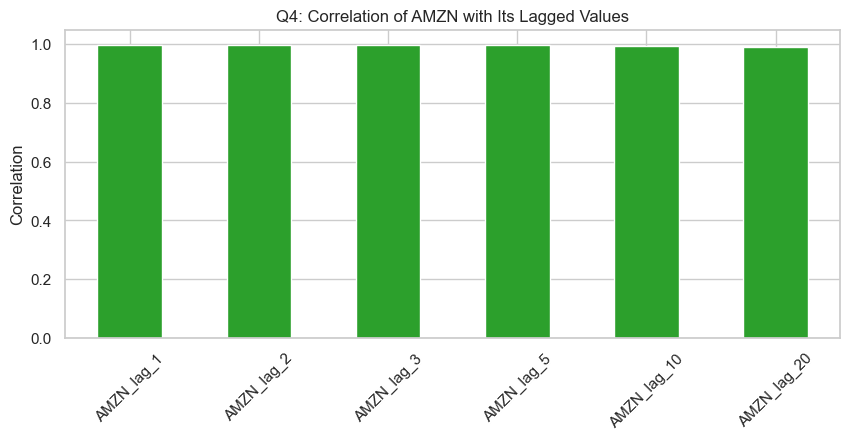

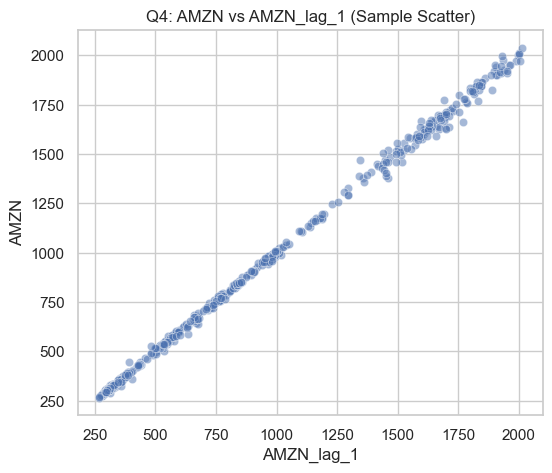

Lag correlations:
AMZN_lag_1     0.999336
AMZN_lag_10    0.994539
AMZN_lag_2     0.998707
AMZN_lag_20    0.990451
AMZN_lag_3     0.998135
AMZN_lag_5     0.997064
Name: AMZN, dtype: float64


In [40]:
# B4) Q4: Are lagged AMZN values informative for current AMZN?
lag_df = df[['AMZN']].copy()
for lag in [1, 2, 3, 5, 10, 20]:
    lag_df[f'AMZN_lag_{lag}'] = lag_df['AMZN'].shift(lag)
lag_df = lag_df.dropna()

lag_cols = [col for col in lag_df.columns if 'lag' in col]
lag_corr = lag_df[['AMZN'] + lag_cols].corr()['AMZN'].drop('AMZN')

fig, ax = plt.subplots(figsize=(10, 4))
lag_corr.plot(kind='bar', color='tab:green', ax=ax)
ax.set_title('Q4: Correlation of AMZN with Its Lagged Values')
ax.set_ylabel('Correlation')
plt.xticks(rotation=45)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sample_df = lag_df.sample(min(600, len(lag_df)), random_state=42)
sns.scatterplot(data=sample_df, x='AMZN_lag_1', y='AMZN', alpha=0.5, ax=ax)
ax.set_title('Q4: AMZN vs AMZN_lag_1 (Sample Scatter)')
plt.show()

print('Lag correlations:')
print(lag_corr.sort_index())

In [41]:
print('\nInterpretation: Strong lag correlations indicate substantial temporal dependency.')


Interpretation: Strong lag correlations indicate substantial temporal dependency.


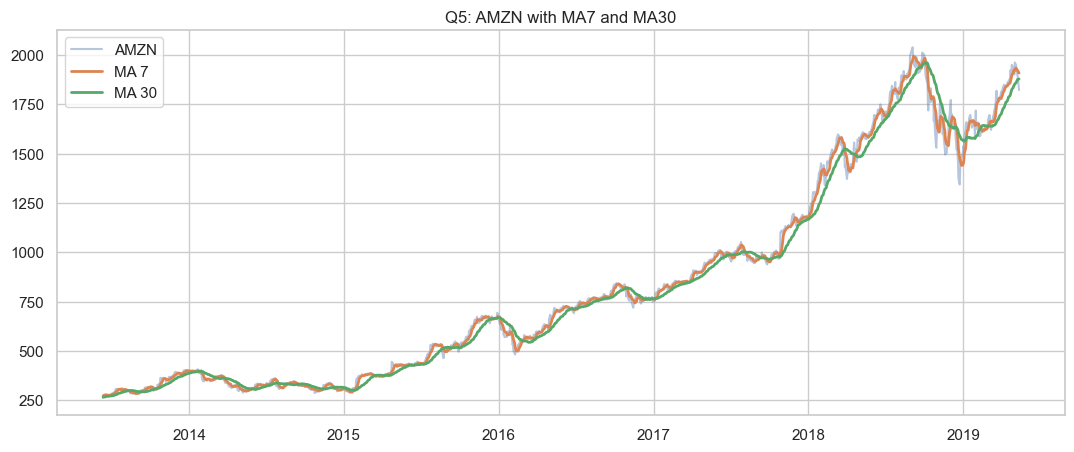

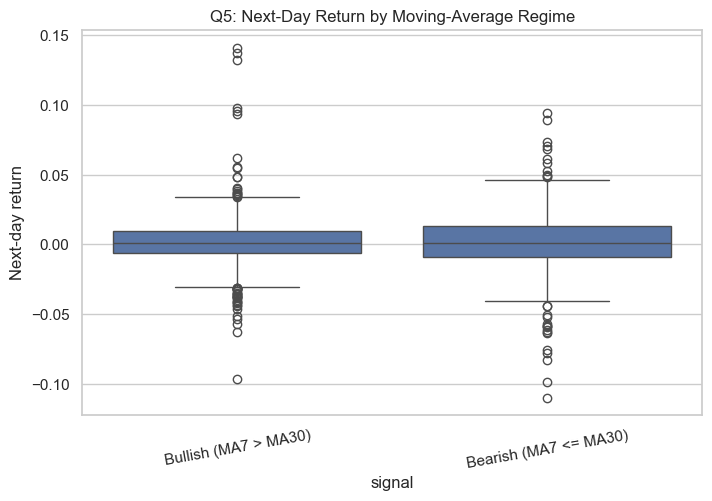

                           mean    median       std  count
signal                                                    
Bearish (MA7 <= MA30)  0.001231  0.001197  0.023160    436
Bullish (MA7 > MA30)   0.001562  0.001103  0.017116   1054


In [42]:
# B5) Q5: Do moving-average regimes relate to next-day AMZN returns?
ma_df = df[['AMZN']].copy()
ma_df['ret_1d'] = ma_df['AMZN'].pct_change()
ma_df['ma_7'] = ma_df['AMZN'].rolling(7).mean()
ma_df['ma_30'] = ma_df['AMZN'].rolling(30).mean()
ma_df['ma_ratio'] = ma_df['ma_7'] / ma_df['ma_30']
ma_df['next_day_return'] = ma_df['ret_1d'].shift(-1)
ma_df['signal'] = np.where(ma_df['ma_7'] > ma_df['ma_30'], 'Bullish (MA7 > MA30)', 'Bearish (MA7 <= MA30)')
ma_df = ma_df.dropna()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ma_df.index, ma_df['AMZN'], label='AMZN', alpha=0.4)
ax.plot(ma_df.index, ma_df['ma_7'], label='MA 7', linewidth=2)
ax.plot(ma_df.index, ma_df['ma_30'], label='MA 30', linewidth=2)
ax.set_title('Q5: AMZN with MA7 and MA30')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=ma_df, x='signal', y='next_day_return', ax=ax)
ax.set_title('Q5: Next-Day Return by Moving-Average Regime')
ax.set_ylabel('Next-day return')
plt.xticks(rotation=10)
plt.show()

signal_perf = ma_df.groupby('signal')['next_day_return'].agg(['mean', 'median', 'std', 'count'])
print(signal_perf)

In [43]:
print('\nInterpretation: MA regime differences suggest momentum context can be informative for next-day returns.')


Interpretation: MA regime differences suggest momentum context can be informative for next-day returns.


In [44]:
# C1) Feature engineering for final-model prediction
model_df = df.copy()

# Target: next-day AMZN
target_col = 'AMZN'
model_df['target_next_day'] = model_df[target_col].shift(-1)

# Lag features for all assets
for col in numeric_cols:
    for lag in [1, 2, 3, 5, 10]:
        model_df[f'{col}_lag_{lag}'] = model_df[col].shift(lag)

# Moving averages and rolling volatility for AMZN
for window in [5, 10, 20, 30]:
    model_df[f'AMZN_ma_{window}'] = model_df['AMZN'].rolling(window).mean()
    model_df[f'AMZN_std_{window}'] = model_df['AMZN'].rolling(window).std()

# One-day returns for all assets
for col in numeric_cols:
    model_df[f'{col}_ret_1d'] = model_df[col].pct_change()

model_df = model_df.dropna()

feature_cols = [col for col in model_df.columns if col != 'target_next_day']
X = model_df[feature_cols]
y = model_df['target_next_day']

# Time-aware train/test split (80/20)
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print(f'Feature count: {len(feature_cols)}')

Train shape: (1192, 36) | Test shape: (298, 36)
Feature count: 36


In [45]:
# C2) Train and evaluate final model (Linear Regression)
def evaluate_regression(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {
        'model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE_%': mape,
        'R2': r2,
    }

final_model = LinearRegression()
final_model.fit(X_train, y_train)
lin_pred = final_model.predict(X_test)

model_results = pd.DataFrame([evaluate_regression('FinalModel_LinearRegression', y_test, lin_pred)])
display(model_results.round(4))

,model,MAE,RMSE,MAPE_%,R2
0,FinalModel_LinearRegression,25.4651,35.9078,1.5259,0.9459


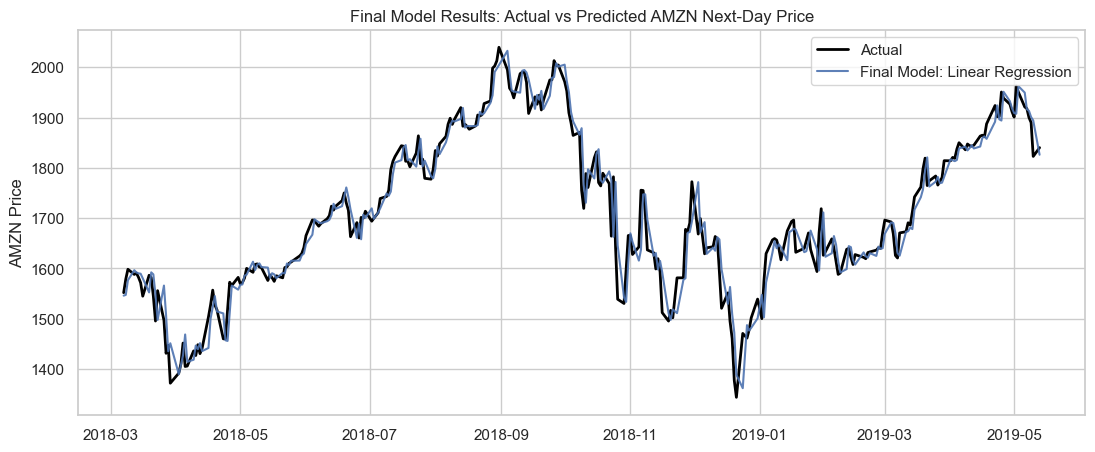

In [46]:
# C3) Final model visualization
result_df = pd.DataFrame(
    {'Actual': y_test, 'LinearRegression_Pred': lin_pred},
    index=y_test.index
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(result_df.index, result_df['Actual'], label='Actual', color='black', linewidth=2)
ax.plot(result_df.index, result_df['LinearRegression_Pred'], label='Final Model: Linear Regression', alpha=0.9)
ax.set_title('Final Model Results: Actual vs Predicted AMZN Next-Day Price')
ax.set_ylabel('AMZN Price')
ax.legend()
plt.show()